In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
print("at directory:", os.getcwd())
print("changing to root directory")
os.chdir("../")
print("at directory:", os.getcwd())

at directory: /Users/wilka/git/research/human-dyna-web/analysis_notebooks
changing to root directory
at directory: /Users/wilka/git/research/human-dyna-web


In [3]:
# import jax
# import jax.numpy as jnp
# import functools
# from functools import partial
# import pandas as pd
# import numpy as np
# from pprint import pprint
# import glob
# from glob import glob
# import matplotlib.pyplot as plt
# import polars as pl
# from tqdm.notebook import tqdm

# from projects.humansf import data_loading
# from projects.humansf import housemaze_analysis
# from projects.humansf import data_loading
# from projects.humansf import housemaze_trainer
# from projects.humansf import housemaze_experiments
# from projects.humansf import networks
# from housemaze.human_dyna import mazes

# from housemaze import renderer
# from housemaze import utils
# from housemaze.human_dyna import multitask_env as maze
# from jaxneurorl import launcher
# from jaxneurorl.agents import value_based_basics as vbb


# from projects.humansf import download_data

In [10]:
from analysis import data_loading
from analysis.download_data import download_user_files

bucket_name = "human-dyna"
prefix = "data/"
#pattern = "data/data_user=*_name=r0-v2*debug=0.json"
human_data_pattern = "data/data_user=*exp3*v5*debug=0.json"
destination_folder = "/Users/wilka/git/research/results/human_dyna/user_data/exp3"

download_user_files(bucket_name, prefix, human_data_pattern, destination_folder)

Downloaded: data/data_user=1020850163_name=exp3-v5-r1-t0_exp=3_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp3/data_user=1020850163_name=exp3-v5-r1-t0_exp=3_debug=0.json
Downloaded: data/data_user=1104389009_name=exp3-v5-r1-t30_exp=3_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp3/data_user=1104389009_name=exp3-v5-r1-t30_exp=3_debug=0.json
Downloaded: data/data_user=1192310572_name=exp3-v5-r1-t30_exp=3_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp3/data_user=1192310572_name=exp3-v5-r1-t30_exp=3_debug=0.json
Downloaded: data/data_user=1246324491_name=exp3-v5-r1-t0_exp=3_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp3/data_user=1246324491_name=exp3-v5-r1-t0_exp=3_debug=0.json
Downloaded: data/data_user=1373019774_name=exp3-v5-r1-t30_exp=3_debug=0.json to /Users/wilka/git/research/results/human_dyna/user_data/exp3/data_user=1373019774_name=exp3-v5-r1-t30_exp=3_debug=0.json
Down

In [13]:
from glob import glob
data_dir = '/Users/wilka/git/research/results/human_dyna/'
files = f'{data_dir}/user_data/*exp3*/*exp3*v5*.json'
user_base_path = f'{data_dir}/user_data'
files = list(set(glob(files)))
len(files)

38

In [14]:
from pprint import pprint
import json
nfinished = 0
for idx, file in enumerate(files):
    with open(file, 'r') as f:
        try:
            data = json.load(f)
        except Exception as e:
            print('-'*25)
            print(idx, os.path.basename(file))
            print(e)
            continue
        if not len(data): continue
        finished = data[-1].get("finished", False)
        if finished:
            print
            nfinished += 1
            print('-'*25)
            print(idx, os.path.basename(file))
            print("\n" + data[-1]['feedback'] or "N/A")
            print('bonus:', data[-1]['bonus'])
            print('feedback:')
            if 'feedback' in data[-2]['data']:
                pprint(data[-2]['data'])

        # else:
        #     print("NOT FINISHED")

-------------------------
0 data_user=3017670921_name=exp3-v5-r1-t30_exp=3_debug=0.json

The input from the arrow keys is a little laggy and sometimes causes the cursor to skip compared to where I want it to be.
bonus: 3
feedback:
{'feedback': "At first I didn't notice that the lettuce was available from the "
             'paths on either side. Once I did notice it, I thought it looked '
             "like it might be a quicker path. I wasn't sure, but I wanted to "
             'try and see if it seemed faster.',
 'question': 'You used a different path as in Phase 1. Please briefly describe '
             'why. For example, did you re-plan how to get the object?'}
-------------------------
2 data_user=3883429642_name=exp3-v5-r1-t0_exp=3_debug=0.json

Everything was fine
bonus: 3
feedback:
{'feedback': 'I use whatever I am familiar with. I felt my path was optimal '
             'and would get me there the fastest without too much thinking.',
 'question': 'You used the same path as in

In [3]:
import json
file = '/Users/wilka/git/research/results/human_dyna/user_data/exp3/data_user=214084446_name=exp3-v5-r1-t30_exp=3_debug=0.json'
with open(file, 'r') as f:
    data = json.load(f)

In [4]:
data_dicts = data

In [13]:
import jax
from analysis import housemaze as housemaze_analysis
from housemaze import utils
from housemaze.human_dyna import multitask_env as maze
from housemaze.human_dyna import mazes
from experiment_utils import SuccessTrackingAutoResetWrapper

dummy_env_params = housemaze_analysis.get_params(mazes.big_practice_maze)
dummy_rng = jax.random.PRNGKey(42)
task_runner = maze.TaskRunner(task_objects=housemaze_analysis.task_objects)
base_env = maze.HouseMaze(
    task_runner=task_runner,
    num_categories=200,
)
web_env = SuccessTrackingAutoResetWrapper(base_env)
example_web_timestep = web_env.reset(dummy_rng, dummy_env_params)

# nenvs=25
# example_timestep = env.reset(dummy_rng, dummy_env_params)


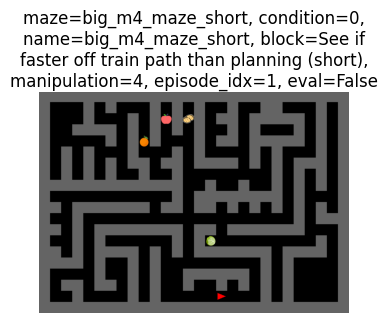

image: 2024-10-20T03:20:10.681Z
action time: 2024-10-20T03:20:11.717Z
action: 2


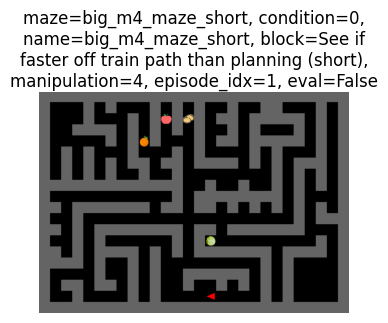

image: 2024-10-20T03:20:11.717Z
action time: 2024-10-20T03:20:11.889Z
action: 2


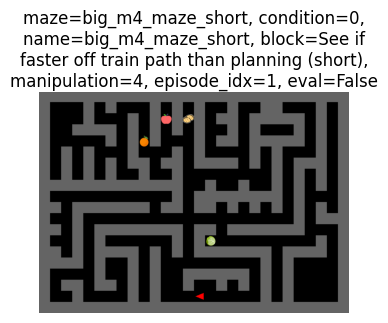

image: 2024-10-20T03:20:11.889Z
action time: 2024-10-20T03:20:12.038Z
action: 2


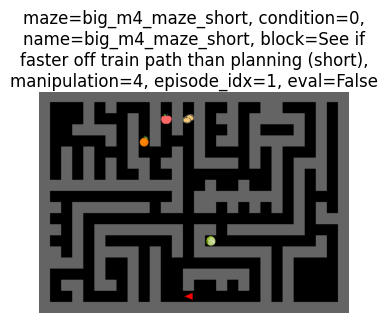

image: 2024-10-20T03:20:12.038Z
action time: 2024-10-20T03:20:12.196Z
action: 2


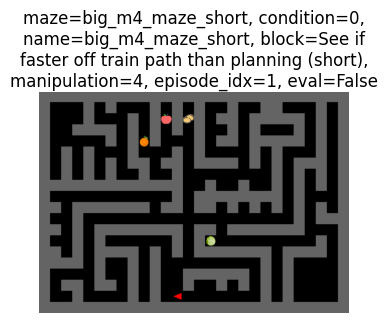

image: 2024-10-20T03:20:12.196Z
action time: 2024-10-20T03:20:12.411Z
action: 2


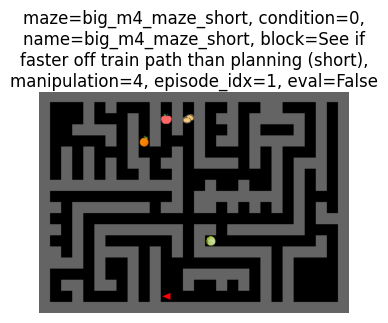

image: 2024-10-20T03:20:12.411Z
action time: 2024-10-20T03:20:12.761Z
action: 0


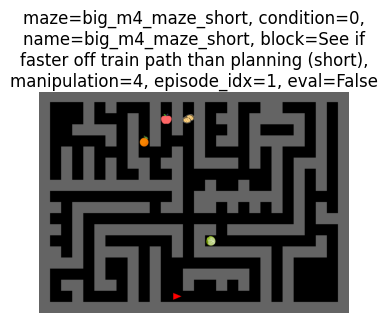

image: 2024-10-20T03:20:12.761Z
action time: 2024-10-20T03:20:12.880Z
action: 3


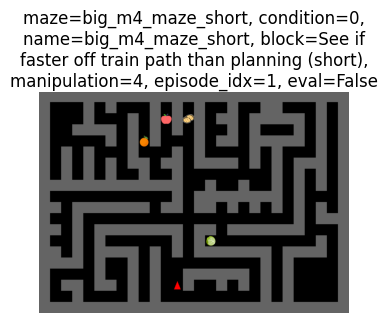

image: 2024-10-20T03:20:12.880Z
action time: 2024-10-20T03:20:13.019Z
action: 3


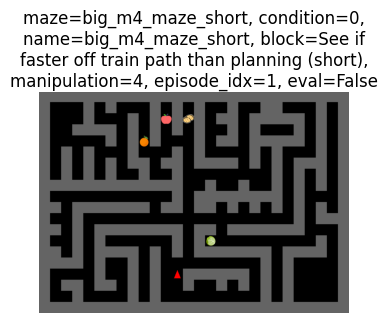

image: 2024-10-20T03:20:13.019Z
action time: 2024-10-20T03:20:13.212Z
action: 3


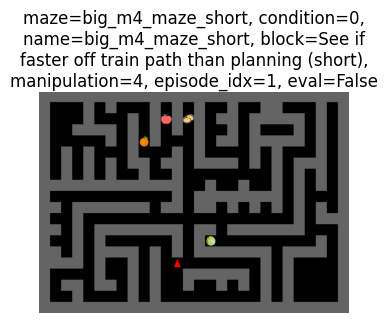

image: 2024-10-20T03:20:13.212Z
action time: 2024-10-20T03:20:13.364Z
action: 0


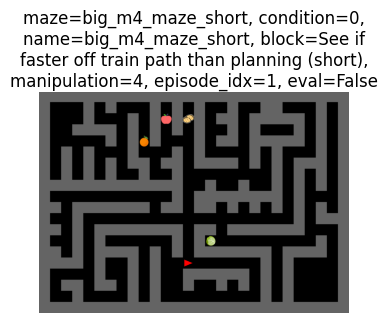

image: 2024-10-20T03:20:13.364Z
action time: 2024-10-20T03:20:13.542Z
action: 3


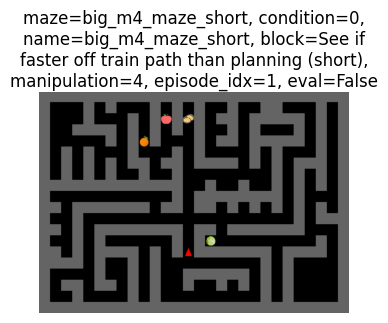

image: 2024-10-20T03:20:13.542Z
action time: 2024-10-20T03:20:13.800Z
action: 3


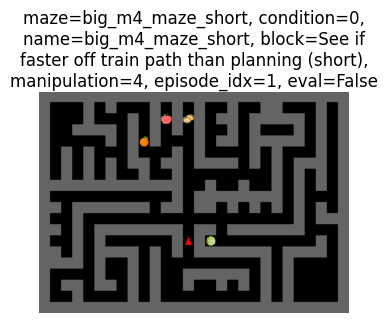

image: 2024-10-20T03:20:13.542Z
action time: 2024-10-20T03:20:13.834Z
action: 3


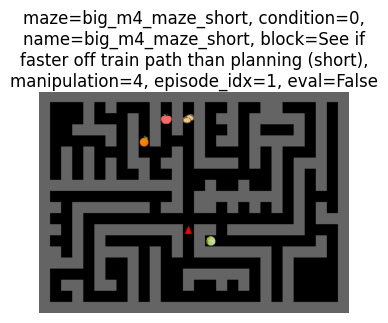

image: 2024-10-20T03:20:13.542Z
action time: 2024-10-20T03:20:13.865Z
action: 3


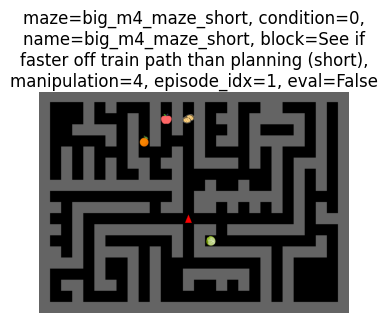

image: 2024-10-20T03:20:13.542Z
action time: 2024-10-20T03:20:13.896Z
action: 3


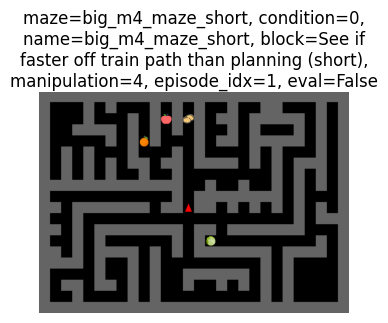

image: 2024-10-20T03:20:13.896Z
action time: 2024-10-20T03:20:13.926Z
action: 3


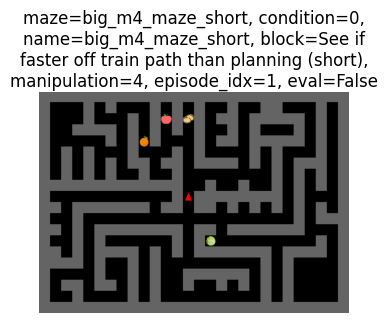

image: 2024-10-20T03:20:13.896Z
action time: 2024-10-20T03:20:13.972Z
action: 3


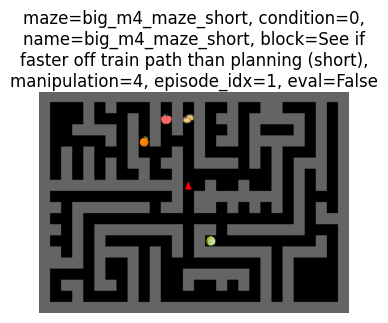

image: 2024-10-20T03:20:13.896Z
action time: 2024-10-20T03:20:14.004Z
action: 3


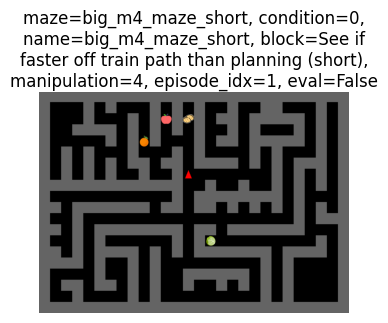

image: 2024-10-20T03:20:13.896Z
action time: 2024-10-20T03:20:14.034Z
action: 3


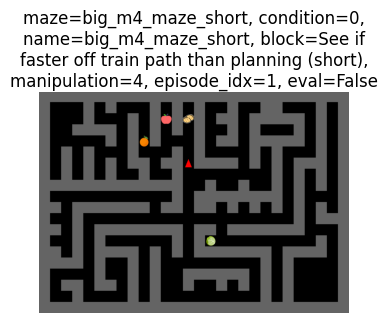

image: 2024-10-20T03:20:13.896Z
action time: 2024-10-20T03:20:14.065Z
action: 3


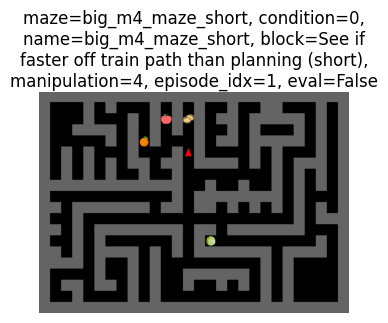

image: 2024-10-20T03:20:13.896Z
action time: 2024-10-20T03:20:14.096Z
action: 3


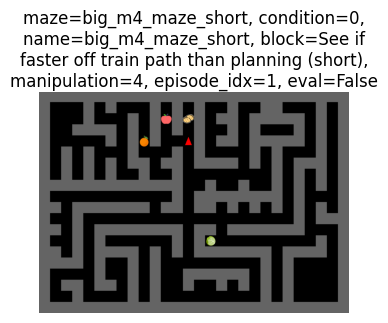

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.128Z
action: 3


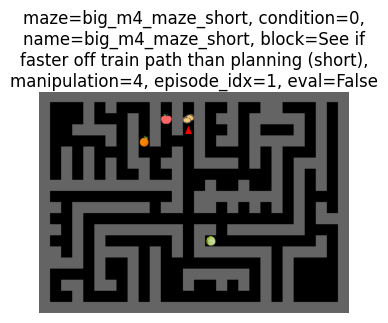

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.159Z
action: 3


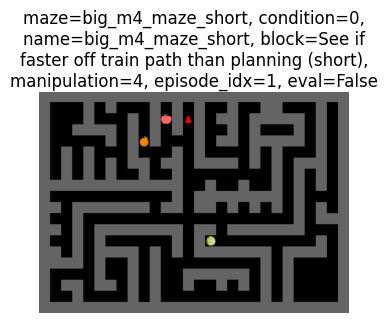

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.190Z
action: 3


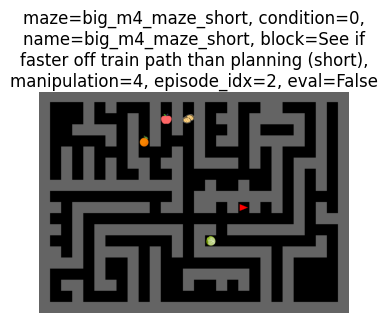

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.222Z
action: 3


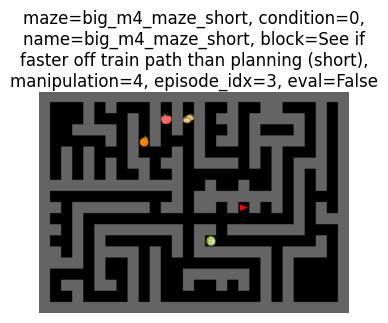

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.269Z
action: 3


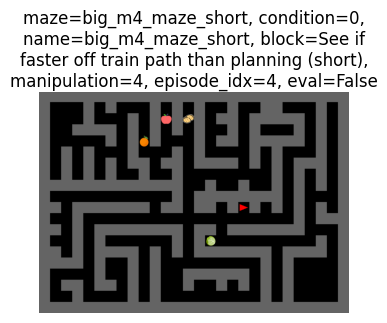

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.300Z
action: 3


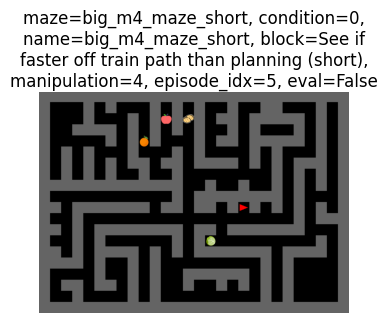

image: 2024-10-20T03:20:14.096Z
action time: 2024-10-20T03:20:14.332Z
action: 3


In [26]:
from analysis.data_loading import get_block_stage_description, dict_to_string, get_timestep
from analysis.housemaze import housemaze_render_fn
import matplotlib.pyplot as plt

# let's just print out the first few time-step to see what they look like
keys = set()
# nidx = 2
nidx = len(data_dicts)
for idx in range(nidx):
    datum = data_dicts[idx]
    # get the information describing block x stage pairs. you can edit this function if you want
    info = get_block_stage_description(datum)
    title = dict_to_string(info)
    if not 'm4_maze_short' in title: continue
    if not title in keys:
        print("="*100)
        keys.add(title)
    
    timestep = get_timestep(datum, example_web_timestep)
    image = housemaze_render_fn(timestep.state)
    # action_taken: int = datum['action_idx']

    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    ax.imshow(image)
    ax.axis('off')
    ax.set_title(title, wrap=True)
    plt.show()

    print('image:', datum['data']['image_seen_time'])
    print('action time:', datum['data']['action_taken_time'])
    print('action:', datum['data']['action_idx'])
    if datum['metadata']['episode_idx'] == 5:
        break
    

In [27]:
datum

{'id': 5320,
 'session_id': 'd480bbca-3c1e-4d63-ab2d-05e1e80582fd',
 'name': 'big_m4_maze_short',
 'stage_idx': 20,
 'data': {'image_seen_time': '2024-10-20T03:20:14.096Z',
  'action_taken_time': '2024-10-20T03:20:14.332Z',
  'computer_interaction': 'ArrowUp',
  'action_name': 'up',
  'action_idx': 3,
  'timelimit': None,
  'timestep': 'hqVzdGF0ZY2ja2V5gqEwzjkdQCqhMc5A4wxfqHN0ZXBfbnVtAKRncmlk3gASoTDeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAGhNoGhMAChN4GhMAChOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0gaEwAKIxNYGhMACiMTaBoTABojE3gaEwAKIxOIGhMACiMTmBoTABojIwgaEwAaIyMYGhMACiMjKBoTAAojIzgaEwAKIyNIGhMAGiMjWBoTAAoTHeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAChNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAfojExgaEwAaIxMoGhMA2iMTOBoTABojE0gaEwAKIxNYGhMAGiMTaBoTABojE3gaEwAKIxOIGhMAGiMTmBoTABojIwgaEwAaIyMYGhMAGiMjKBoTABojIzgaEwAKIyNIGhMAGiMjWBoTAAoTLeABqhMIGhMAChMYGhMAChMoGhMAGhM4GhMAGhNIGhMAGhNYGhMAGhNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0g

In [29]:
data_dicts[idx-1]

{'id': 5319,
 'session_id': 'd480bbca-3c1e-4d63-ab2d-05e1e80582fd',
 'name': 'big_m4_maze_short',
 'stage_idx': 20,
 'data': {'image_seen_time': '2024-10-20T03:20:14.096Z',
  'action_taken_time': '2024-10-20T03:20:14.300Z',
  'computer_interaction': 'ArrowUp',
  'action_name': 'up',
  'action_idx': 3,
  'timelimit': None,
  'timestep': 'hqVzdGF0ZY2ja2V5gqEwzjkdQCqhMc5A4wxfqHN0ZXBfbnVtAKRncmlk3gASoTDeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAGhNoGhMAChN4GhMAChOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0gaEwAKIxNYGhMACiMTaBoTABojE3gaEwAKIxOIGhMACiMTmBoTABojIwgaEwAaIyMYGhMACiMjKBoTAAojIzgaEwAKIyNIGhMAGiMjWBoTAAoTHeABqhMIGhMAChMYGhMAChMoGhMAChM4GhMAGhNIGhMAChNYGhMAChNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAfojExgaEwAaIxMoGhMA2iMTOBoTABojE0gaEwAKIxNYGhMAGiMTaBoTABojE3gaEwAKIxOIGhMAGiMTmBoTABojIwgaEwAaIyMYGhMAGiMjKBoTABojIzgaEwAKIyNIGhMAGiMjWBoTAAoTLeABqhMIGhMAChMYGhMAChMoGhMAGhM4GhMAGhNIGhMAGhNYGhMAGhNoGhMAChN4GhMAGhOIGhMAChOYGhMAGiMTCBoTAAojExgaEwAaIxMoGhMACiMTOBoTABojE0g